# Language Task
# Sentiment Analysis Text Classification with RNN.

## Text Preprocessing, Tokenization, and Sequence Padding:


### Installing necessary python libraries

In [2]:
!pip install contractions wordcloud --quiet
!pip install contractions wordcloud gensim --quiet

### Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the dataset

In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/AI_ML/2408388_Anuska_G.C._AI_Assignment/NLP/news_category.csv')
print("Shape of the dataset is::", df.shape)
print("\nColumns in the dataset:", df.columns.tolist())
print("\nSample rows:")
df.head()

Shape of the dataset is:: (11025, 2)

Columns in the dataset: ['headline', 'category']

Sample rows:


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


Dataset Stats

In [5]:
print(f"Total headlines      : {len(df)}")
print(f"Number of classes    : {df['category'].nunique()}")
print(f"\nClass distribution:")
print(df['category'].value_counts())

# Headline length in characters
df['headline_length'] = df['headline'].apply(len)
print(f"\nAverage headline length : {df['headline_length'].mean():.1f} chars")
print(f"Median headline length  : {df['headline_length'].median():.1f} chars")
print(f"Max headline length     : {df['headline_length'].max()} chars")

Total headlines      : 11025
Number of classes    : 5

Class distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64

Average headline length : 59.7 chars
Median headline length  : 60.0 chars
Max headline length     : 172 chars


Visulization of the Dataset

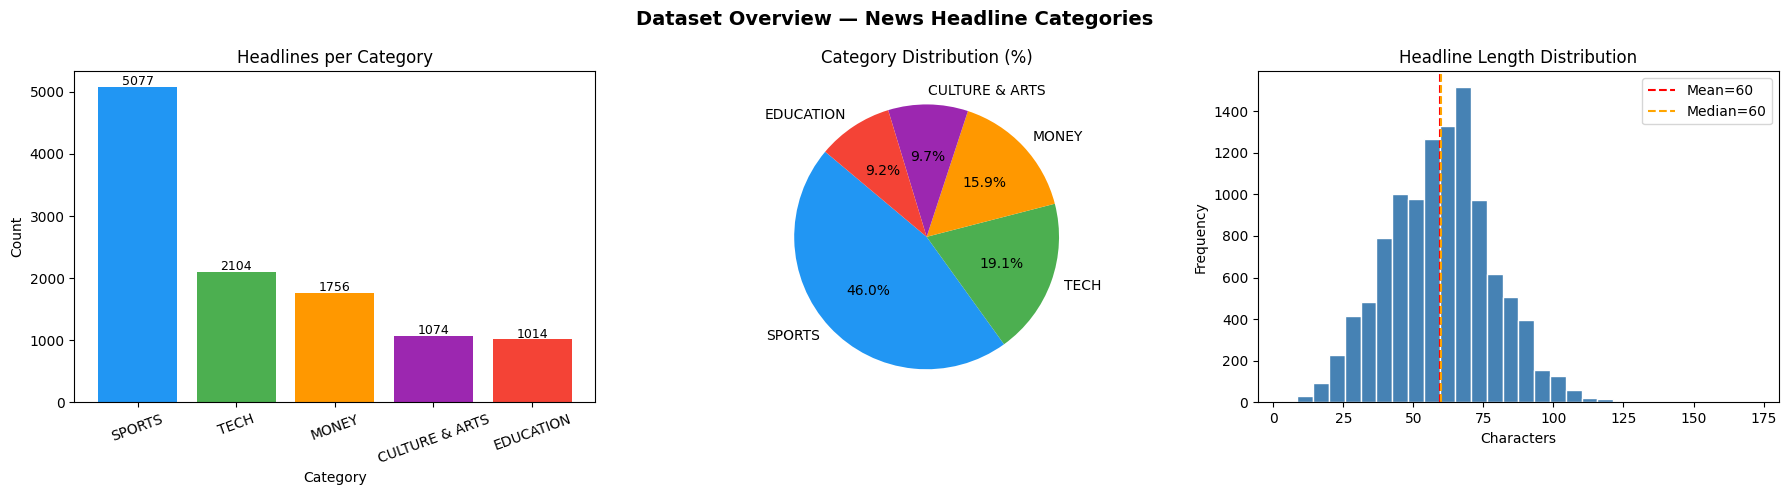

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Dataset Overview — News Headline Categories", fontsize=14, fontweight='bold')

# --- Bar chart: headlines per category ---
counts = df['category'].value_counts()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Headlines per Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

# --- Pie chart: percentage distribution ---
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title("Category Distribution (%)")

# --- Headline length histogram ---
axes[2].hist(df['headline_length'], bins=30, color='steelblue', edgecolor='white')
axes[2].axvline(df['headline_length'].mean(), color='red', linestyle='--',
                label=f"Mean={df['headline_length'].mean():.0f}")
axes[2].axvline(df['headline_length'].median(), color='orange', linestyle='--',
                label=f"Median={df['headline_length'].median():.0f}")
axes[2].set_title("Headline Length Distribution")
axes[2].set_xlabel("Characters")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()

Import all libraries needed for preprocessing

In [7]:
import re
import nltk
import contractions  # NEW: not in your worksheet — handles "don't" → "do not"

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
wordnet = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Helper Function to CLean the Text

In [8]:
def lower_order(text):
    """Convert all text to lowercase for uniformity."""
    return text.lower()

def remove_urls(text):
    """Remove http/https URLs and www links"""
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_emoji(text):
    """Remove unicode emoji characters"""
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def removeunwanted_characters(text):
    """Remove @mentions, #hashtags, numbers, punctuation """
    text = re.sub(r'@\w+', '', text)       # remove @mentions
    text = re.sub(r'#\w+', '', text)       # remove #hashtags
    text = re.sub(r'\d+', '', text)        # remove numbers (added for headlines)
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ----- NEW for this assignment -----
def handle_contractions(text):
    """
    Expand contractions BEFORE removing punctuation.
    e.g. "don't" → "do not", "it's" → "it is"
    This is required by the assignment spec — not in your worksheet.
    Must run BEFORE removeunwanted_characters() because the apostrophe
    gets stripped otherwise, turning "don't" → "dont" silently.
    """
    return contractions.fix(text)


Main function to Clean the text

In [9]:
def text_cleaning_pipeline(text, rule="lemmatize"):
    """
    Full pipeline — combines your worksheet functions + contraction handling.
    Steps:
      1. Lowercase
      2. Expand contractions
      3. Remove URLs
      4. Remove emojis
      5. Remove unwanted characters
      6. Tokenize by splitting on spaces
      7. Remove stopwords
      8. Lemmatize (or stem)
    """
    text = lower_order(text)
    text = handle_contractions(text)   # NEW step
    text = remove_urls(text)
    text = remove_emoji(text)
    text = removeunwanted_characters(text)

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]

    if rule == "lemmatize":
        tokens = [wordnet.lemmatize(word, pos='v') for word in tokens]
    elif rule == "stem":
        from nltk.stem import PorterStemmer
        porter = PorterStemmer()
        tokens = [porter.stem(word) for word in tokens]

    return " ".join(tokens)

Test for Cleaning

In [10]:
# Quick test
sample = "Apple's CEO doesn't think the NFL's team should get $100M funding!"
print("Original :", sample)
print("Cleaned  :", text_cleaning_pipeline(sample))

Original : Apple's CEO doesn't think the NFL's team should get $100M funding!
Cleaned  : apples ceo think nfls team get fund


Clean the Dataset

In [11]:
print("Cleaning headlines...")

# Drop any empty rows first (same pattern as your worksheet)
df = df.dropna(subset=['headline']).reset_index(drop=True)

# Apply the pipeline — same .apply(lambda x: ...) pattern as your worksheet
df['cleaned'] = df['headline'].apply(lambda x: text_cleaning_pipeline(x))

# Show a before/after comparison
for i in range(3):
    print(f"ORIGINAL : {df['headline'][i]}")
    print(f"CLEANED  : {df['cleaned'][i]}")
    print()

Cleaning headlines...
ORIGINAL : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
CLEANED  : new documentary capture complexity child immigrants

ORIGINAL : Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
CLEANED  : twitch ban gamble sit streamer scam folks

ORIGINAL : 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
CLEANED  : reboot clever navelgazey look inside tv reboot



Visulaization after Cleaning

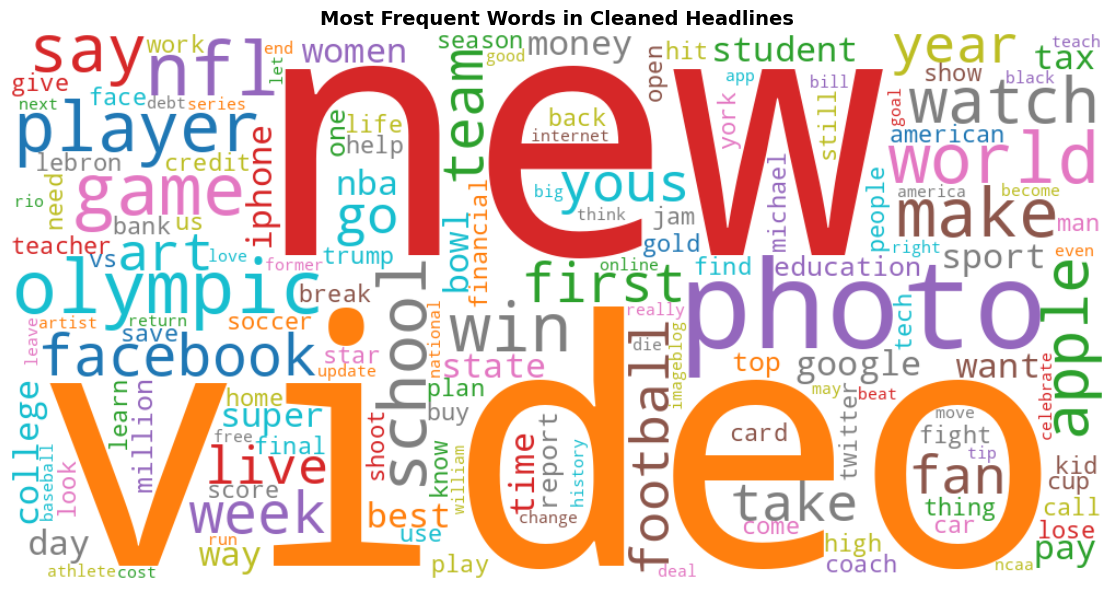

In [12]:
from wordcloud import WordCloud

all_words = ' '.join(df['cleaned'].values)

wc = WordCloud(
    width=1000, height=500,
    background_color='white',
    max_words=150,
    colormap='tab10',
    collocations=False
).generate(all_words)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Cleaned Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()

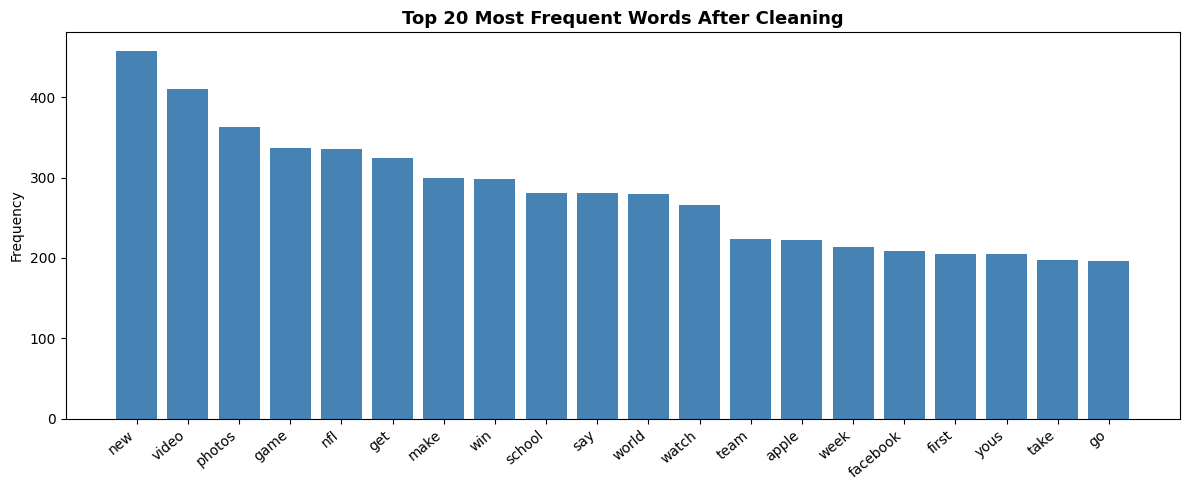

In [13]:
# Top 20 words as a bar chart
from collections import Counter
word_freq = Counter(all_words.split())
top_20 = word_freq.most_common(20)
words, freqs = zip(*top_20)

plt.figure(figsize=(12, 5))
plt.bar(words, freqs, color='steelblue')
plt.title("Top 20 Most Frequent Words After Cleaning", fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.ylabel("Frequency")
plt.tight_layout()

Tokenization and Padding

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# --- Split BEFORE tokenization  ---
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df['cleaned'],
    df['category'],
    test_size=0.2,
    random_state=42,
    stratify=df['category']   # ensures each category has proportional representation
)

print(f"Training samples : {len(X_train_raw)}")
print(f"Testing samples  : {len(X_test_raw)}")

# --- Encode labels ---
# LabelEncoder maps: SPORTS→4, TECH→3, EDUCATION→0, MONEY→2, CULTURE & ARTS→1 (alphabetical)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_raw)
y_test_enc  = le.transform(y_test_raw)

num_classes = len(le.classes_)
print(f"\nClasses: {le.classes_}")
print(f"Number of classes: {num_classes}")

# Convert integer labels to one-hot vectors for categorical_crossentropy
# e.g.  SPORTS (4) → [0, 0, 0, 0, 1]
y_train_cat = to_categorical(y_train_enc, num_classes)
y_test_cat  = to_categorical(y_test_enc, num_classes)
print(f"\ny_train_cat shape: {y_train_cat.shape}")

Training samples : 8820
Testing samples  : 2205

Classes: ['CULTURE & ARTS' 'EDUCATION' 'MONEY' 'SPORTS' 'TECH']
Number of classes: 5

y_train_cat shape: (8820, 5)


Keras Tokenizer

In [15]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 1: Fit the tokenizer on training text only
# vocab_size limits vocabulary to the top N most common words
VOCAB_SIZE = 10000
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

word_index = tokenizer.word_index
print(f"Vocabulary size (unique words): {len(word_index)}")

# Step 2: Convert text → sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

print(f"\nExample headline  : {list(X_train_raw)[0]}")
print(f"As integer sequence: {X_train_seq[0]}")

# Step 3: Percentile-based padding length
# Using 95th percentile avoids making all sequences as long as the longest headline
# This saves memory and speeds up training — better than using max length
all_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(all_lengths, 95))
print(f"\n95th percentile sequence length → MAX_LEN = {MAX_LEN}")
print(f"(Max possible was: {max(all_lengths)} — we avoid padding to that extreme)")

# Step 4: Apply padding
# post padding adds zeros at the end of shorter sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape: {X_train_pad.shape}")
print(f"X_test_pad shape : {X_test_pad.shape}")

Vocabulary size (unique words): 11530

Example headline  : need know apple fbi showdown dc
As integer sequence: [59, 58, 14, 461, 2067, 789]

95th percentile sequence length → MAX_LEN = 11
(Max possible was: 18 — we avoid padding to that extreme)

X_train_pad shape: (8820, 11)
X_test_pad shape : (2205, 11)


Model Building and Training

Hyperparamters for NLP

In [16]:
EMBED_DIM   = 64    # size of each word's embedding vector
RNN_UNITS   = 64    # neurons in the RNN/LSTM layer
BATCH_SIZE  = 32
EPOCHS      = 30    # early stopping will cut this short automatically

print("Model config:")
print(f"  Vocab size  : {VOCAB_SIZE}")
print(f"  Max seq len : {MAX_LEN}")
print(f"  Embed dim   : {EMBED_DIM}")
print(f"  RNN units   : {RNN_UNITS}")
print(f"  Num classes : {num_classes}")

Model config:
  Vocab size  : 10000
  Max seq len : 11
  Embed dim   : 64
  RNN units   : 64
  Num classes : 5


Callbacks

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

# Define callbacks_list here to ensure it's available
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks_list = [early_stop, reduce_lr]

# Simple RNN

## Building Simple RNN Model

In [18]:
tf.random.set_seed(42)

# Model 1 — Simple RNN (UPDATED: add input_length)
rnn_model = Sequential(name="SimpleRNN_Model")
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
rnn_model.add(SimpleRNN(RNN_UNITS,
                        dropout=0.5,
                        recurrent_dropout=0.5,
                        kernel_regularizer=l2(0.001)))
rnn_model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
rnn_model.add(Dropout(0.5))
rnn_model.add(Dense(num_classes, activation='softmax'))
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,501 (2.48 MB)

 Trainable params: 650,501 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling

In [19]:
rnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## Training

In [20]:
history_rnn = rnn_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS, # Use the defined EPOCHS constant
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.3393 - loss: 1.6883 - val_accuracy: 0.4546 - val_loss: 1.5328 - learning_rate: 0.0010
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4534 - loss: 1.5565 - val_accuracy: 0.4546 - val_loss: 1.5170 - learning_rate: 0.0010
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4594 - loss: 1.5161 - val_accuracy: 0.4546 - val_loss: 1.5015 - learning_rate: 0.0010
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4607 - loss: 1.5030 - val_accuracy: 0.4546 - val_loss: 1.4937 - learning_rate: 0.0010
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4612 - loss: 1.4725 - val_accuracy: 0.4546 - val_loss: 1.4626 - learning_rate: 0.0010
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4613 - loss: 1.4164 - val_accuracy: 0.4546 - val_loss: 1.2879 - learning_rate: 0.0010
Epoch 7/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4656 - loss: 1.

## Simple RNN Accuracy and Loss Graph

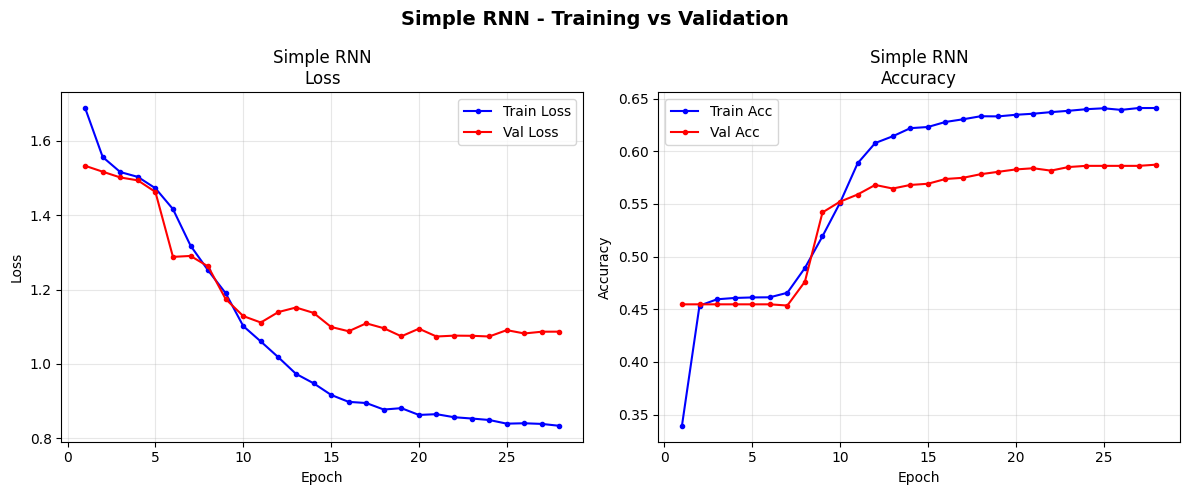

In [29]:
import matplotlib.pyplot as plt

def plot_history(history, model_name, ax_loss, ax_acc):
    """Plots training vs validation loss and accuracy for one model."""
    epochs_ran = range(1, len(history.history['loss']) + 1)

    ax_loss.plot(epochs_ran, history.history['loss'],     'b-o', markersize=3, label='Train Loss')
    ax_loss.plot(epochs_ran, history.history['val_loss'], 'r-o', markersize=3, label='Val Loss')
    ax_loss.set_title(f"{model_name}\nLoss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(epochs_ran, history.history['accuracy'],     'b-o', markersize=3, label='Train Acc')
    ax_acc.plot(epochs_ran, history.history['val_accuracy'], 'r-o', markersize=3, label='Val Acc')
    ax_acc.set_title(f"{model_name}\nAccuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

# Call to plot_history for Simple RNN from original cell 5Eo1E5pyTXQR (adjusted to new function signature)
# Note: To maintain previous behavior, we create a figure here.
fig_rnn, axes_rnn = plt.subplots(1, 2, figsize=(12, 5))
fig_rnn.suptitle("Simple RNN - Training vs Validation", fontsize=14, fontweight='bold')
plot_history(history_rnn, "Simple RNN", axes_rnn[0], axes_rnn[1])
plt.tight_layout()
plt.show()

## Evaluating Simple RNN Model on Test Set

In [22]:
loss_rnn, accuracy_rnn = rnn_model.evaluate(X_test_pad, y_test_cat, verbose=0)

print(f"Simple RNN Test Accuracy: {accuracy_rnn*100:.2f}%")
print(f"Simple RNN Test Loss: {loss_rnn:.4f}")


Simple RNN Test Accuracy: 59.50%
Simple RNN Test Loss: 1.0125


# LSTM Model

# Building LSTM Model

In [23]:
tf.random.set_seed(42)

lstm_model = Sequential(name="LSTM_Model")
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
lstm_model.add(LSTM(RNN_UNITS,
                    dropout=0.5,
                    recurrent_dropout=0.3,
                    kernel_regularizer=l2(0.001)))
lstm_model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
lstm_model.add(Dropout(0.4))
lstm_model.add(Dense(num_classes, activation='softmax'))

lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,269 (2.58 MB)

 Trainable params: 675,269 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling

In [24]:
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


## Training

In [25]:
history_lstm = lstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS, # Use the defined EPOCHS constant
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.5180 - loss: 1.2724 - val_accuracy: 0.5964 - val_loss: 0.9842 - learning_rate: 0.0010
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6221 - loss: 0.8928 - val_accuracy: 0.6395 - val_loss: 0.9013 - learning_rate: 0.0010
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.6849 - loss: 0.7252 - val_accuracy: 0.6803 - val_loss: 0.8038 - learning_rate: 0.0010
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7478 - loss: 0.5940 - val_accuracy: 0.7755 - val_loss: 0.7236 - learning_rate: 0.0010
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8399 - loss: 0.4585 - val_accuracy: 0.7948 - val_loss: 0.7244 - learning_rate: 0.0010
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8934 - loss: 0.3503 - val_accuracy: 0.7880 - val_loss: 0.7875 - learning_rate: 0.0010
Epoch 7/30
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9039 - loss: 

## LSTM Accuracy and Loss Graph

Final Training Loss:     0.1979
Final Training Accuracy: 95.62%
Final Validation Loss:   0.8530
Final Validation Accuracy: 80.95%


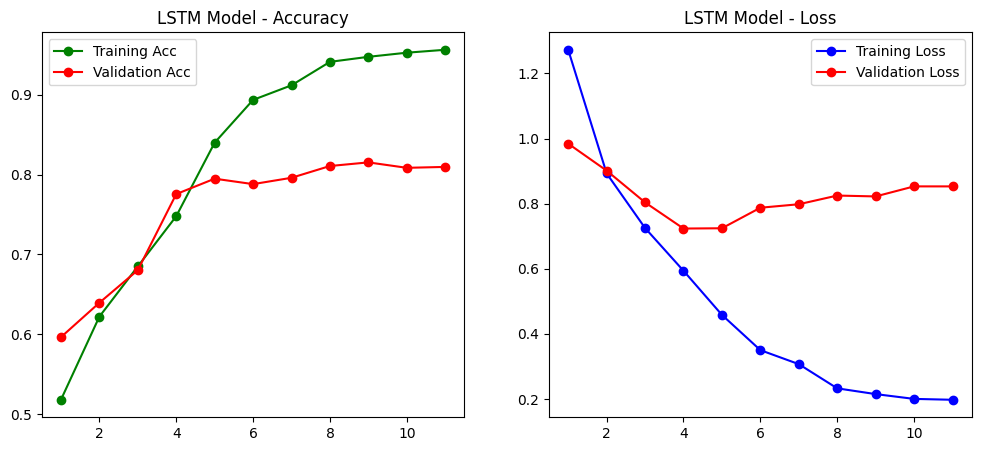

In [26]:
# Extract final training and validation results
final_loss = history_lstm.history['loss'][-1]
final_acc = history_lstm.history['accuracy'][-1]
val_loss = history_lstm.history['val_loss'][-1]
val_acc = history_lstm.history['val_accuracy'][-1]

print(f"Final Training Loss:     {final_loss:.4f}")
print(f"Final Training Accuracy: {final_acc*100:.2f}%")
print(f"Final Validation Loss:   {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
plot_history(history_lstm, "LSTM Model")


## Evaluating LSTM Model on Test Set

In [27]:
loss_lstm, accuracy_lstm = lstm_model.evaluate(X_test_pad, y_test_cat, verbose=0)

print(f"LSTM Test Accuracy: {accuracy_lstm*100:.2f}%")
print(f"LSTM Test Loss: {loss_lstm:.4f}")

LSTM Test Loss: 0.7005
LSTM Test Accuracy: 76.78%


## LSTM Model Training History Plot

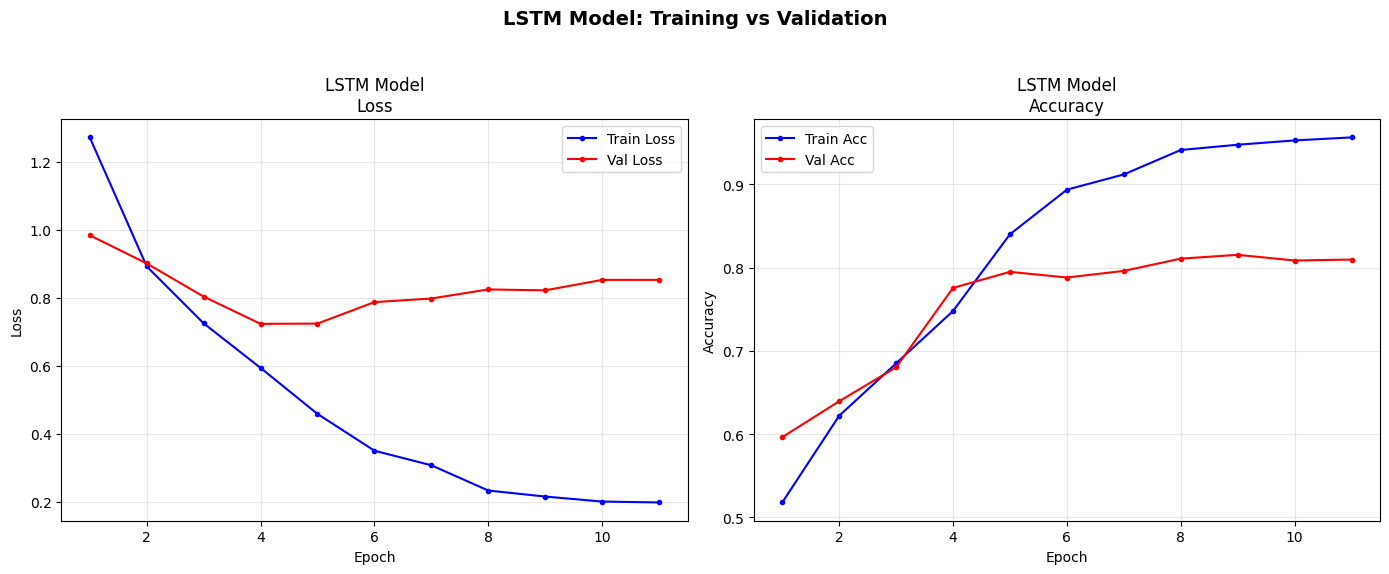

In [30]:
import matplotlib.pyplot as plt

fig_lstm, axes_lstm = plt.subplots(1, 2, figsize=(14, 6))
fig_lstm.suptitle("LSTM Model: Training vs Validation", fontsize=14, fontweight='bold')

plot_history(history_lstm, "LSTM Model", axes_lstm[0], axes_lstm[1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# LSTM + Word2Vec

## Load and Prepare Word2Vec Embeddings

In [32]:
import gensim.downloader as api

# Load a PRETRAINED model (this is what the task requires)
print("Loading pretrained GloVe vectors...")
w2v_model = api.load('glove-wiki-gigaword-50')  # 50-dim, small and fast
EMBED_DIM_W2V = 50  # must match 50

# Build embedding matrix — same code as yours
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
covered = 0
for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE and word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]
        covered += 1

print(f"Words covered by pretrained embeddings: {covered} / {min(VOCAB_SIZE, len(tokenizer.word_index))}")

Loading pretrained GloVe vectors...
[==================================================] 100.0% 66.0/66.0MB downloaded
Words covered by pretrained embeddings: 8965 / 10000


## Building LSTM model with Word2vec

In [33]:
# Build model
tf.random.set_seed(42)
lstm_w2v_model = Sequential(name="LSTM_Word2Vec_Model")
lstm_w2v_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM_W2V,
    weights=[embedding_matrix],
    input_length=MAX_LEN,       # <-- added
    trainable=True
))
lstm_w2v_model.add(LSTM(RNN_UNITS, dropout=0.5, recurrent_dropout=0.5, kernel_regularizer=l2(0.001)))
lstm_w2v_model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
lstm_w2v_model.add(Dropout(0.5))
lstm_w2v_model.add(Dense(num_classes, activation='softmax'))

lstm_w2v_model.build(input_shape=(None, MAX_LEN))

lstm_w2v_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,925 (2.04 MB)

 Trainable params: 533,925 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling

In [34]:
lstm_w2v_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])



## Train on Test Set

In [35]:
history_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.5808 - loss: 1.2170 - val_accuracy: 0.7676 - val_loss: 0.7855 - learning_rate: 0.0010
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7322 - loss: 0.8804 - val_accuracy: 0.8277 - val_loss: 0.6265 - learning_rate: 0.0010
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7765 - loss: 0.7552 - val_accuracy: 0.8401 - val_loss: 0.5553 - learning_rate: 0.0010
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8149 - loss: 0.6615 - val_accuracy: 0.8492 - val_loss: 0.5288 - learning_rate: 0.0010
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8316 - loss: 0.6000 - val_accuracy: 0.8549 - val_loss: 0.5071 - learning_rate: 0.0010
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8466 - loss: 0.5530 - val_accuracy: 0.8639 - val_loss: 0.4828 - learning_rate: 0.0010
Epoch 7/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8634 - loss:


## LSTM with Word2Vec Accuracy and Loss Graph

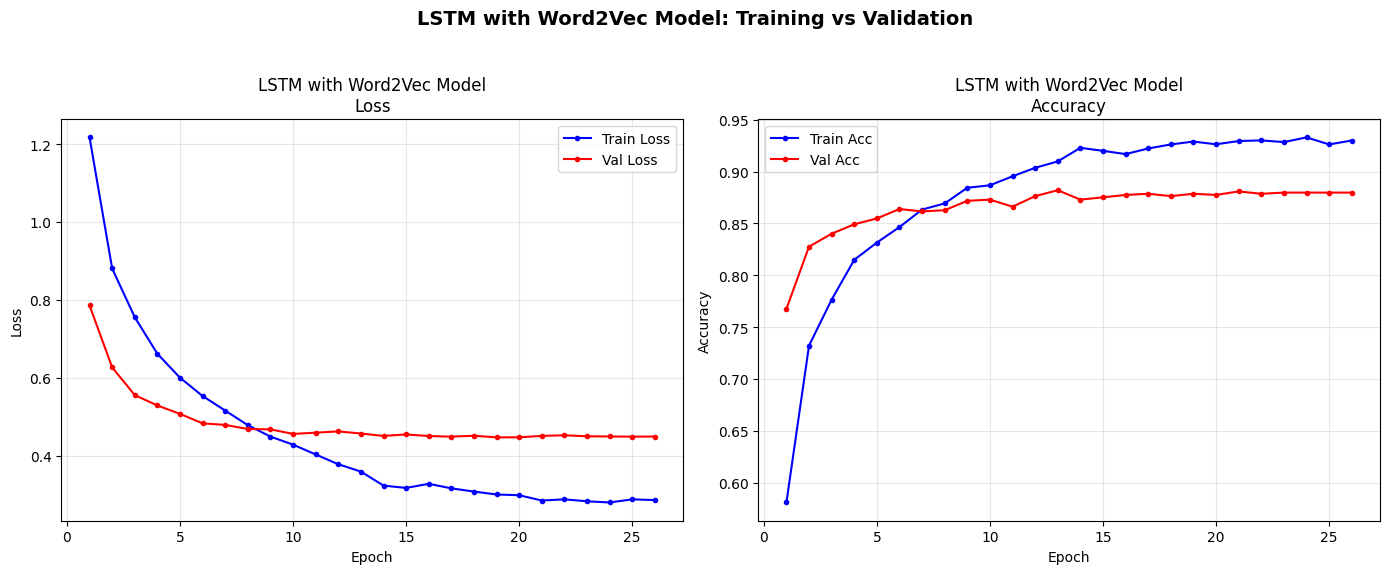

In [37]:
import matplotlib.pyplot as plt

fig_lstm_w2v, axes_lstm_w2v = plt.subplots(1, 2, figsize=(14, 6))
fig_lstm_w2v.suptitle("LSTM with Word2Vec Model: Training vs Validation", fontsize=14, fontweight='bold')

plot_history(history_w2v, "LSTM with Word2Vec Model", axes_lstm_w2v[0], axes_lstm_w2v[1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Testing LSTM with Word2Vec Model on Test Set

In [38]:
loss_lstm_w2v, accuracy_lstm_w2v = lstm_w2v_model.evaluate(X_test_pad, y_test_cat, verbose=0)

print(f"LSTM with Word2Vec Test Loss: {loss_lstm_w2v:.4f}")
print(f"LSTM with Word2Vec Test Accuracy: {accuracy_lstm_w2v*100:.2f}%")

LSTM with Word2Vec Test Loss: 0.4553
LSTM with Word2Vec Test Accuracy: 86.98%


# Final Accuracy and Loss Graph on Test Set

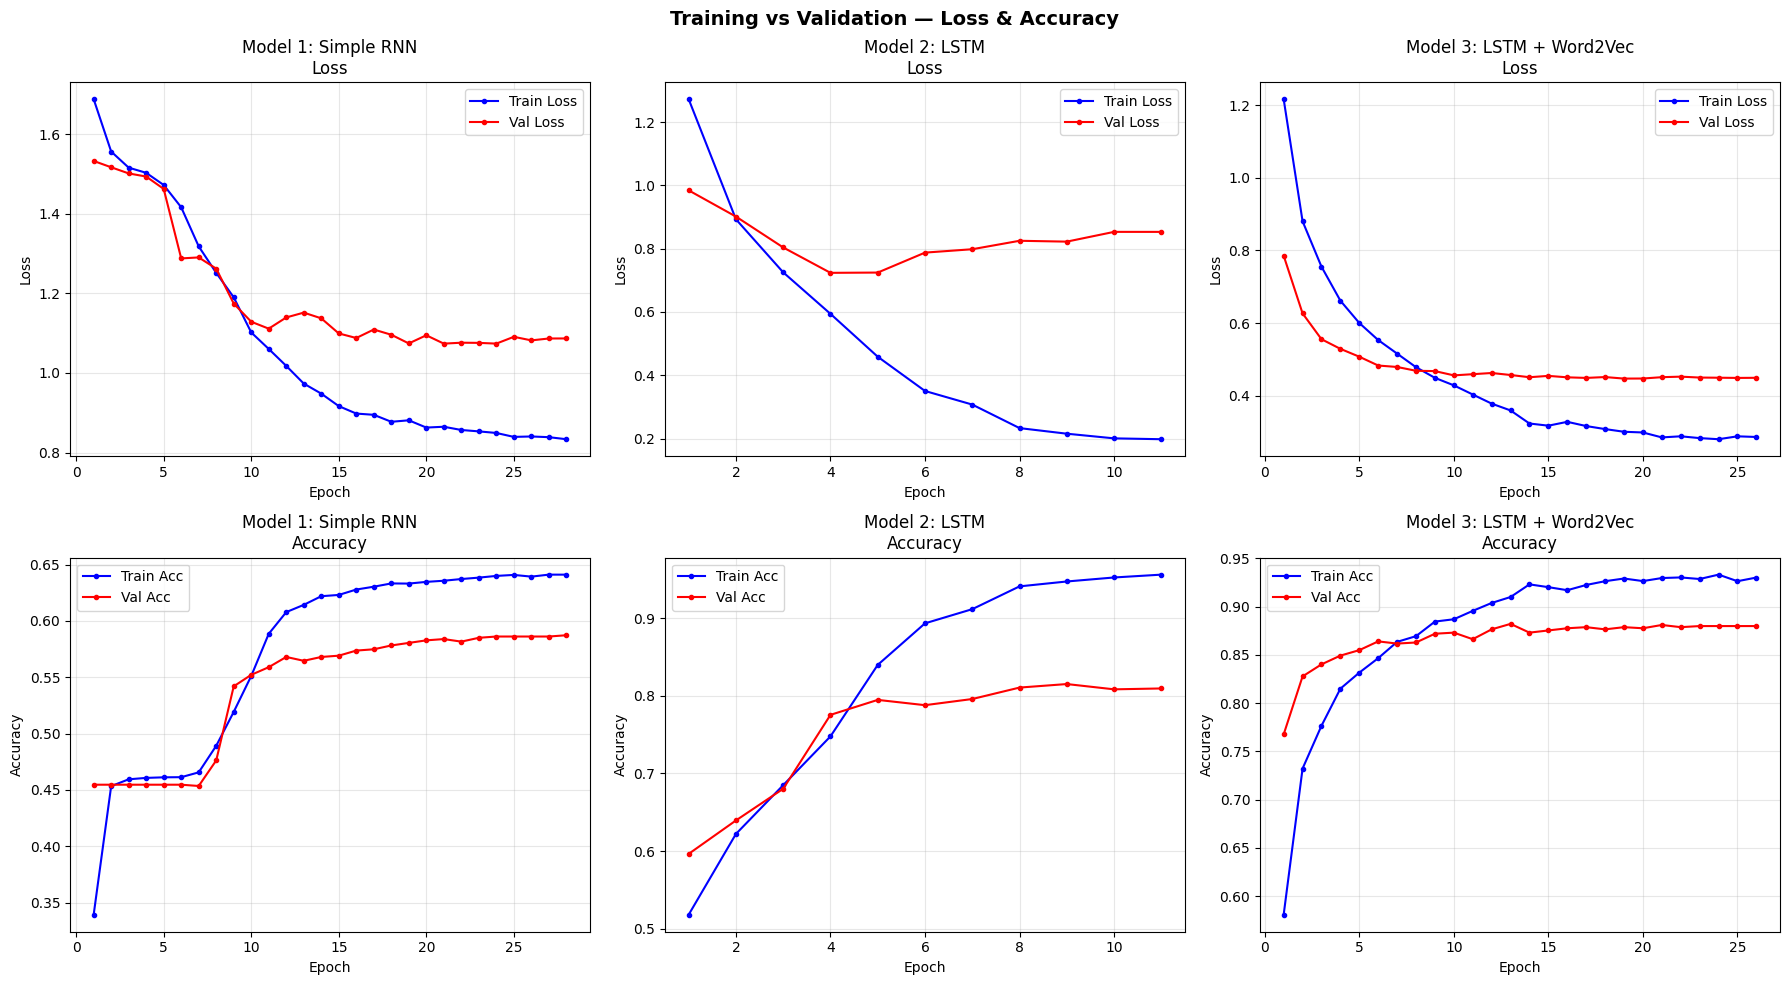

In [40]:
# ============================================================
# CELL 22 — Training Curves: Loss & Accuracy per Model
# ============================================================

# The plot_history function definition has been moved to cell 5Eo1E5pyTXQR.
# This cell now only contains the calls to plot the history for all three models.

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training vs Validation — Loss & Accuracy", fontsize=14, fontweight='bold')

plot_history(history_rnn,  "Model 1: Simple RNN",         axes[0][0], axes[1][0])
plot_history(history_lstm, "Model 2: LSTM",                axes[0][1], axes[1][1])
plot_history(history_w2v,  "Model 3: LSTM + Word2Vec",     axes[0][2], axes[1][2])

plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/AI_ML/2408388_Anuska_G.C._AI_Assignment/NLP/training_curves.png',
            # dpi=150, bbox_inches='tight')
plt.show()

# Classification Report for 3 models

In [42]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Get predictions for each model
y_pred_rnn_proba = rnn_model.predict(X_test_pad)
y_pred_rnn = np.argmax(y_pred_rnn_proba, axis=1)

y_pred_lstm_proba = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_lstm_proba, axis=1)

y_pred_w2v_proba = lstm_w2v_model.predict(X_test_pad)
y_pred_w2v = np.argmax(y_pred_w2v_proba, axis=1)

# Define true labels (y_test_enc contains the integer-encoded labels)
y_true = y_test_enc

model_names = ["Simple RNN", "LSTM", "LSTM + Word2Vec"]
preds = [y_pred_rnn, y_pred_lstm, y_pred_w2v]

for name, pred in zip(model_names, preds):
    print(f"\n{'='*20} {name} Report {'='*20}")
    print(classification_report(y_true, pred, target_names=le.classes_))

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

==================== Simple RNN Report ====================
                precision    recall  f1-score   support

CULTURE & ARTS       0.00      0.00      0.00       215
     EDUCATION       0.00      0.00      0.00       203
         MONEY       0.00      0.00      0.00       351
        SPORTS       0.93      0.91      0.92      1015
          TECH       0.32      0.93      0.48       421

      accuracy                           0.60      2205
     macro avg       0.25      0.37      0.28      2205
  weighted avg       0.49      0.60      0.51      2205


==================== LSTM Report ====================
                precision    recall  f1-score   support

CULTURE & ARTS       0.53      0.60      0.56       215
     EDUCATION       0.51      0.56      0.53       203
         MONEY       0.64      0.59      0.61       351
        SPORTS       0.91      0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Confusion Matrix Comparison

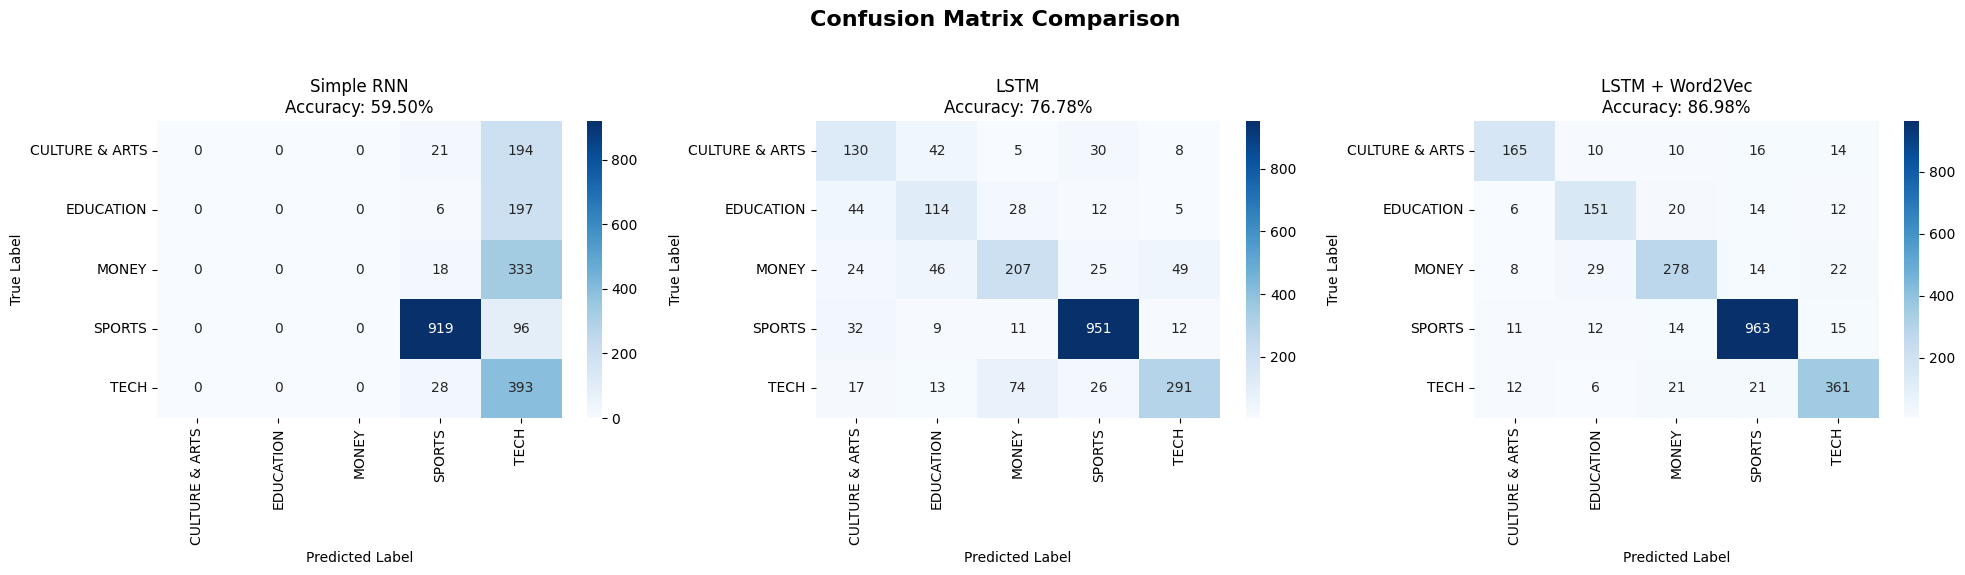

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# True labels are y_test_enc
y_true = y_test_enc

model_names = ["Simple RNN", "LSTM", "LSTM + Word2Vec"]
preds = [y_pred_rnn, y_pred_lstm, y_pred_w2v]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Confusion Matrix Comparison", fontsize=16, fontweight='bold')

for i, (name, pred) in enumerate(zip(model_names, preds)):
    cm = confusion_matrix(y_true, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=axes[i]
    )
    axes[i].set_title(f'{name}\nAccuracy: {accuracy_score(y_true, pred)*100:.2f}%')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Final comparison of 3 Model

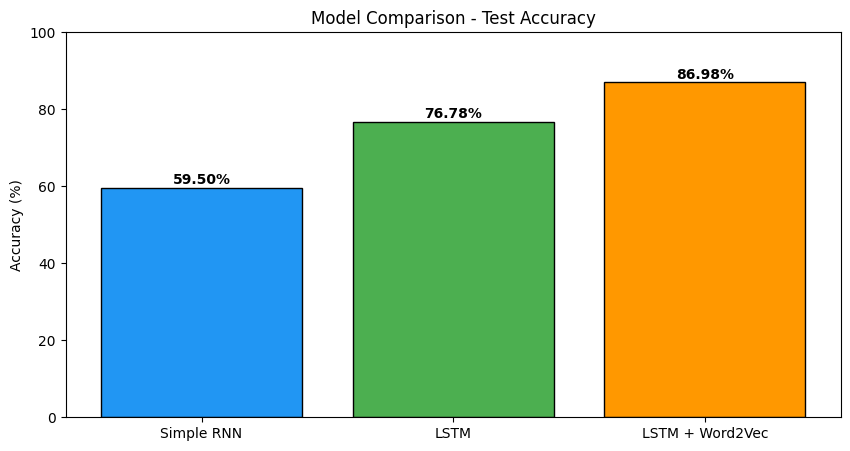

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracy scores
acc_scores = [accuracy_score(y_test_enc, p) * 100 for p in preds]

plt.figure(figsize=(10, 5))
plt.bar(model_names, acc_scores, color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='black')
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison - Test Accuracy")
plt.ylim(0, 100)

for i, score in enumerate(acc_scores):
    plt.text(i, score + 1, f"{score:.2f}%", ha='center', fontweight='bold')

# Error Analysis

In [44]:
#Find Misclassified Examples
# We'll use LSTM + Word2Vec (Model 3)
best_preds = y_pred_w2v

# Align test indices with original dataframe
test_idx = list(X_test_raw.index)
X_test_list  = list(X_test_raw)
y_test_list  = list(y_test_raw)

print("MISCLASSIFIED EXAMPLES (Model 3 — LSTM + Word2Vec):")
print("=" * 70)

count = 0
for i in range(len(X_test_list)):
    true_label = le.classes_[y_test_enc[i]]
    pred_label = le.classes_[best_preds[i]]

    if true_label != pred_label:
        # Find original (uncleaned) headline
        original = df.loc[test_idx[i], 'headline']
        print(f"Example {count + 1}:")
        print(f"  Original headline : {original}")
        print(f"  Cleaned headline  : {X_test_list[i]}")
        print(f"  True label        : {true_label}")
        print(f"  Predicted label   : {pred_label}")
        print()
        count += 1
        if count == 3:
            break

print("-" * 70)
print("""
ERROR ANALYSIS DISCUSSION:
--------------------------
1. Class Overlap: Some categories share vocabulary. For example, a Sports
   headline mentioning "Apple Watch" (tech brand in a sports context) may
   confuse the model into predicting TECH instead of SPORTS.

2. Class Imbalance: SPORTS has ~46% of all headlines. The model is heavily
   exposed to sports content, so it may over-predict SPORTS for ambiguous
   headlines. Notice the confusion matrix — most errors likely involve
   SPORTS being predicted when the truth is EDUCATION or CULTURE & ARTS.

3. Short Headlines: Very short headlines after cleaning (2-3 words) lose
   context, making it impossible for the model to distinguish categories.

4. SimpleRNN vs LSTM: The SimpleRNN (Model 1) suffers from the vanishing
   gradient problem — it forgets earlier words in longer headlines. LSTM
   with its memory gates retains more context, explaining its higher accuracy.

POTENTIAL IMPROVEMENTS:
-----------------------
- Use class_weight in model.fit() to penalise errors on minority classes
- Add a second LSTM layer (stacked LSTM) for richer representations
- Use Bidirectional LSTM to read sequences both forward and backward
- Apply pre-trained GloVe or FastText embeddings (larger than our Word2Vec)
- Use a Transformer-based model (e.g., DistilBERT) for state-of-the-art results
""")

MISCLASSIFIED EXAMPLES (Model 3 — LSTM + Word2Vec):
Example 1:
  Original headline : Judicial Negligence Compounds Political Negligence In South Carolina
  Cleaned headline  : judicial negligence compound political negligence south carolina
  True label        : EDUCATION
  Predicted label   : SPORTS

Example 2:
  Original headline : Tales From The Autism Spectrum: My Friend AmberDawn...
  Cleaned headline  : tales autism spectrum friend amberdawn
  True label        : CULTURE & ARTS
  Predicted label   : EDUCATION

Example 3:
  Original headline : Should I Go Back to Grad School?
  Cleaned headline  : go back grad school
  True label        : MONEY
  Predicted label   : EDUCATION

----------------------------------------------------------------------

ERROR ANALYSIS DISCUSSION:
--------------------------
1. Class Overlap: Some categories share vocabulary. For example, a Sports
   headline mentioning "Apple Watch" (tech brand in a sports context) may
   confuse the model into predictin

In [47]:
!pip install gradio --quiet

import gradio as gr

# Use the best performing model for the GUI
BEST_MODEL = lstm_w2v_model   # swap to lstm_model if Word2Vec model underperforms

def predict_category(headline_text):
    """
    Takes a raw headline string from the user, runs the full pipeline,
    and returns a predicted category with confidence scores.
    """
    if not headline_text.strip():
        return "Please enter a headline.", {}

    # Step 1: Clean the input the same way we cleaned training data
    cleaned = text_cleaning_pipeline(headline_text)

    if not cleaned.strip():
        return "Headline too short after cleaning.", {}

    # Step 2: Convert to sequence using the SAME tokenizer fitted on training data
    seq = tokenizer.texts_to_sequences([cleaned])

    # Step 3: Pad to MAX_LEN
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # Step 4: Predict
    probs = BEST_MODEL.predict(padded, verbose=0)[0]

    # Step 5: Map to category names
    confidence_dict = {le.classes_[i]: float(probs[i]) for i in range(num_classes)}
    predicted_class = le.classes_[np.argmax(probs)]
    confidence = float(np.max(probs))

    result = f"Predicted Category: **{predicted_class}** (confidence: {confidence*100:.1f}%)"
    return result, confidence_dict


# Example headlines to help the user test the app
examples = [
    ["Apple announces new iPhone with AI chip"],
    ["NFL quarterback wins championship title"],
    ["Government increases student loan interest rates"],
    ["Stock markets hit record high after Fed decision"],
    ["Broadway musical wins Tony award for best play"]
]

# Build the Gradio interface
interface = gr.Interface(
    fn=predict_category,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Type or paste a news headline here...",
        label="News Headline"
    ),
    outputs=[
        gr.Markdown(label="Prediction"),
        gr.Label(num_top_classes=5, label="Confidence per Category")
    ],
    title="📰 News Headline Category Classifier",
    description=(
        "Enter any news headline\n"
        "**\nSPORTS | TECH | EDUCATION | MONEY | CULTURE & ARTS**\n\n"
        "Model: LSTM with Word2Vec Embeddings"
    ),
    examples=examples,
    theme=gr.themes.Soft()
)

interface.launch(share=True)  # share=True gives a public link that works in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://36665637c172cdf426.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
